# Etapa 1 | Análise Exploratória de Dados
## N.O.V.A | Classificação de qualidade de frutas

## Contexto



O Stockly foi desenvolvido na disciplina **Projetos de Engenharia 3**, em que a turma simulou uma empresa para construir um sistema inteligente de gestão de estoque. A turma foi dividida em equipes de marketing, gestão e prototipagem.

Dentro da prototipagem, a N.O.V.A reuniu os dois serviços de inteligência artificial do sistema. A pesquisa, modelagem e implementação desses dois serviços ficaram sob minha responsabilidade individual.

Este notebook cobre a pesquisa da classificação de qualidade de frutas.

## Objetivo



Esta etapa define a base que seguirá para o treinamento. A análise verifica a qualidade dos dados, a confiabilidade dos sensores, a relação entre os valores dos sensores e a classe, possíveis redundâncias entre sensores e se a classificação deve usar um único modelo ou modelos separados por fruta.

## Dataset



O conjunto público contém leituras de Orange, Pineapple, Banana e Tomato. Cada registro possui temperatura, umidade, luminosidade, concentração de CO2 e um rótulo Good ou Bad.

Segundo a documentação do dataset, esse rótulo indica se as condições ambientais são ótimas ou subótimas para prevenção da deterioração, e não uma inspeção direta do estado da fruta.

O dataset foi publicado por Nshekanabo Marius e Stanley Mugisha em 2025 no Mendeley Data, sob o título *A Multi-Parameter Dataset for Machine Learning Based Fruit Spoilage Prediction in an IoT-Enabled Cold Storage System*.

Os nomes Light (Fux) e CO2 (pmm) são mantidos no código como aparecem no arquivo CSV. Na documentação da fonte, as unidades são descritas como Lux e ppm, respectivamente.

[Fonte do dataset no Mendeley Data](https://data.mendeley.com/datasets/czz68d9fwj/1)

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import entropy, spearmanr
from sklearn.feature_selection import mutual_info_classif

## Preparação do Dataset


In [2]:
dados_brutos = pd.read_csv(Path("dataset_frutas.csv"))
dados_brutos["Posicao_original"] = np.arange(1, len(dados_brutos) + 1)

display(dados_brutos.head())

,Fruit,Temp,Humid (%),Light (Fux),CO2 (pmm),Class,Posicao_original
0,Orange,22,95,7.358649,361,Good,1
1,Orange,24,95,14.835898,370,Bad,2
2,Pineapple,25,95,10.104045,355,Bad,3
3,Banana,25,89,20.179643,388,Good,4
4,Tomato,23,90,12.621448,316,Good,5


In [3]:
estrutura = pd.DataFrame({
    "tipo": dados_brutos.drop(columns="Posicao_original").dtypes.astype(str),
    "nulos": dados_brutos.drop(columns="Posicao_original").isna().sum(),
    "unicos": dados_brutos.drop(columns="Posicao_original").nunique()
})

display(estrutura)

,tipo,nulos,unicos
Fruit,object,0,4
Temp,int64,0,7
Humid (%),int64,0,25
Light (Fux),float64,0,323
CO2 (pmm),int64,0,333
Class,object,0,3


In [4]:
display(
    dados_brutos["Class"]
    .value_counts()
    .rename("quantidade")
    .to_frame()
)

,quantidade
Class,
Good,5667
Bad,4617
BAD,711


Não há valores ausentes e as variáveis foram lidas no formato esperado. O alvo aparece com duas grafias para Bad, então o rótulo será padronizado.

## Padronização do alvo

In [5]:
dados_brutos["Class"] = dados_brutos["Class"].str.strip().str.title()

display(dados_brutos["Class"].value_counts().rename("quantidade").to_frame())

,quantidade
Class,
Good,5667
Bad,5328


## Registros duplicados

In [6]:
colunas_sensores = ["Temp", "Humid (%)", "Light (Fux)", "CO2 (pmm)"]
colunas_registro = ["Fruit", *colunas_sensores, "Class"]

duplicatas_excedentes = dados_brutos.duplicated(
    subset=colunas_registro,
    keep="first"
).sum()

grupos_com_conflito = (
    dados_brutos
    .groupby(["Fruit", *colunas_sensores])["Class"]
    .nunique()
    .gt(1)
    .sum()
)

display(pd.DataFrame({
    "resultado": [duplicatas_excedentes, grupos_com_conflito]
}, index=[
    "cópias excedentes",
    "leituras idênticas com classes diferentes"
]))

,resultado
cópias excedentes,2880
leituras idênticas com classes diferentes,0


Como se observa, as repetições não acrescentam informação nova e nenhuma leitura idêntica recebeu classes diferentes, o que mostra consistência. Portanto, as duplicatas serão removidas, evitando dados repetidos em treino e teste, que causariam um grande problema.

In [7]:
dados = (
    dados_brutos
    .drop_duplicates(subset=colunas_registro, keep="first")
    .copy()
)

print(f"Linhas após a deduplicação: {len(dados):,}")

Linhas após a deduplicação: 8,115


## Verificação inicial dos sensores

Antes de analisar a relação com a classe, serão verificadas as faixas dos sensores e possíveis descontinuidades entre seus valores. A maior lacuna entre leituras consecutivas é calculada para cada variável, permitindo identificar mudanças de escala ou faixas isoladas que mereçam investigação.

In [8]:
resumo_lacunas = []

for sensor in colunas_sensores:
    valores = np.sort(dados[sensor].unique())
    diferencas = np.diff(valores)
    indice = int(np.argmax(diferencas))

    resumo_lacunas.append({
        "sensor": sensor,
        "mínimo": valores.min(),
        "máximo": valores.max(),
        "maior_lacuna": diferencas[indice],
        "antes_da_lacuna": valores[indice],
        "depois_da_lacuna": valores[indice + 1]
    })

resumo_lacunas = pd.DataFrame(resumo_lacunas).set_index("sensor")
display(resumo_lacunas.round(3))

,mínimo,máximo,maior_lacuna,antes_da_lacuna,depois_da_lacuna
sensor,,,,,
Temp,21.000,27.000,1.000,21.000,22.000
Humid (%),71.000,95.000,1.000,71.000,72.000
Light (Fux),4.221,268.448,76.821,23.527,100.348
CO2 (pmm),20.000,478.000,30.000,46.000,76.000


Light é a única variável cuja sequência de valores se divide em duas faixas muito afastadas, antes e depois da lacuna. Isso exige investigar onde essas leituras aparecem e quais suas implicações para a classificação das frutas.


### Posição das leituras de Light

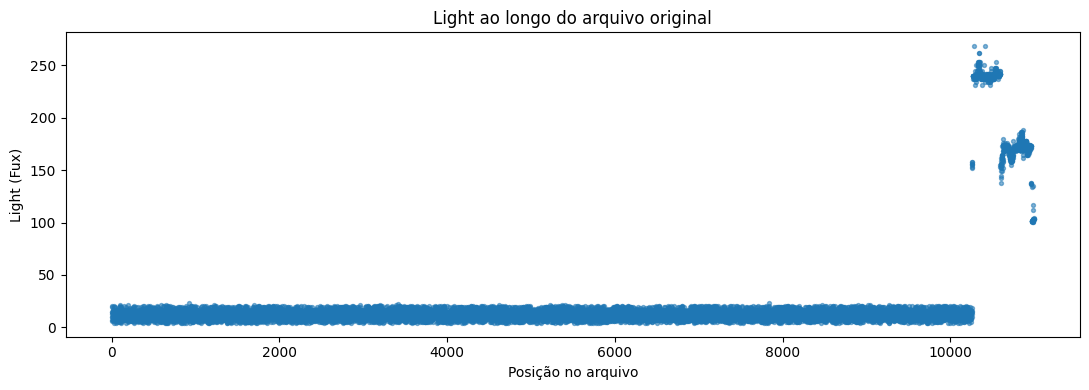

In [9]:
valores_light = np.sort(dados["Light (Fux)"].unique())
lacunas_light = np.diff(valores_light)
indice_lacuna = int(np.argmax(lacunas_light))

limite_light = (
    valores_light[indice_lacuna] +
    valores_light[indice_lacuna + 1]
) / 2

plt.figure(figsize=(11, 4))
plt.scatter(
    dados_brutos["Posicao_original"],
    dados_brutos["Light (Fux)"],
    s=8,
    alpha=0.55
)
plt.xlabel("Posição no arquivo")
plt.ylabel("Light (Fux)")
plt.title("Light ao longo do arquivo original")
plt.tight_layout()
plt.show()

In [10]:
bloco_final_bruto = dados_brutos[dados_brutos["Light (Fux)"] > limite_light]
bloco_final = dados[dados["Light (Fux)"] > limite_light]

resumo_bloco = pd.DataFrame({
    "linhas no arquivo original": [len(bloco_final_bruto)],
    "registros únicos": [len(bloco_final)],
    "primeira posição": [bloco_final_bruto["Posicao_original"].min()],
    "última posição": [bloco_final_bruto["Posicao_original"].max()],
    "frutas presentes": [", ".join(bloco_final_bruto["Fruit"].unique())],
    "classes presentes": [", ".join(bloco_final_bruto["Class"].unique())]
})

display(resumo_bloco)

,linhas no arquivo original,registros únicos,primeira posição,última posição,frutas presentes,classes presentes
0,739,482,10257,10995,Tomato,Bad


As leituras acima da lacuna aparecem concentradas em um bloco contínuo no final do arquivo e somente em Tomato Bad. Isso indica que os valores altos de Light estão associados a um trecho específico dos dados (parte final) e não distribuídos de forma semelhante entre as demais frutas e classes.

Por isso, Light será analisada por fruta e classe antes da decisão sobre sua permanência na etapa de modelagem.

### Light nas quatro frutas

In [11]:
def entropia_alvo(y):
    proporcoes = np.bincount(y) / len(y)
    return entropy(proporcoes)

linhas_light = []

for fruta in ["Banana", "Orange", "Pineapple", "Tomato"]:
    grupo = dados[dados["Fruit"] == fruta]
    y = (grupo["Class"] == "Bad").astype(int).to_numpy()
    h = entropia_alvo(y)

    valores_mi = []
    for semente in range(20):
        mi = mutual_info_classif(
            grupo[["Light (Fux)"]],
            y,
            discrete_features=False,
            random_state=semente
        )[0]
        valores_mi.append(mi / h)

    good = grupo.loc[grupo["Class"] == "Good", "Light (Fux)"]
    bad = grupo.loc[grupo["Class"] == "Bad", "Light (Fux)"]

    linhas_light.append({
        "Fruit": fruta,
        "Good mínimo": good.min(),
        "Good máximo": good.max(),
        "Bad mínimo": bad.min(),
        "Bad máximo": bad.max(),
        "MI normalizada de Light": np.mean(valores_mi)
    })

diagnostico_light = pd.DataFrame(linhas_light).set_index("Fruit")
display(diagnostico_light.round(3))

,Good mínimo,Good máximo,Bad mínimo,Bad máximo,MI normalizada de Light
Fruit,,,,,
Banana,7.089,23.527,10.222,22.640,0.310
Orange,4.221,13.274,13.880,20.290,1.000
Pineapple,12.065,14.511,4.636,15.084,0.762
Tomato,5.925,18.589,11.271,268.448,0.678


Light reúne dois problemas diferentes. Em Orange, Good e Bad ocupam faixas completamente separadas, fazendo com que a variável praticamente determine a classe sozinha. Em Tomato, aparece uma mudança abrupta de escala, concentrada em um bloco específico no final do arquivo.

Portanto, Light apresenta uma relação determinística com o alvo em uma fruta e um comportamento inconsistente de escala em outra. Essas duas evidências são mais que suficientes para **remover** a variável das features a serem utilizadas na modelagem.

Ainda resta decidir se o problema de Tomato está restrito a Light ou se as 482 observações do bloco final também apresentam valores anormais nos outros sensores, a depender do caso, esses dados serão excluídos ou mantidos. Para isso, Temp, Humid e CO2 serão comparados com os demais registros de Tomato Bad.


### O problema de Light invalida também os registros do bloco final?



Para verificar se as 482 observações devem ser removidas por inteiro, os registros Tomato Bad são separados em dois grupos. O primeiro reúne as observações do bloco final com Light acima da lacuna encontrada, enquanto o segundo reúne os demais registros Tomato Bad.

Também será usada a faixa de valores de Temp, Humid e CO2 observada em todos os registros de Tomato. Isso permite verificar se o bloco final apresenta valores anormais nesses sensores ou se o problema está concentrado em Light.

In [12]:
tomato_bad = dados[
    (dados["Fruit"] == "Tomato") &
    (dados["Class"] == "Bad")
].copy()

tomato_bad["Grupo"] = np.where(
    tomato_bad["Light (Fux)"] > limite_light,
    "Bloco final de Tomato Bad",
    "Outros registros de Tomato Bad"
)

In [13]:
comparacao_bloco = []

for sensor in ["Temp", "Humid (%)", "CO2 (pmm)"]:
    grupos = {
        "Bloco final de Tomato Bad": tomato_bad.loc[
            tomato_bad["Grupo"] == "Bloco final de Tomato Bad",
            sensor
        ],
        "Outros registros de Tomato Bad": tomato_bad.loc[
            tomato_bad["Grupo"] == "Outros registros de Tomato Bad",
            sensor
        ],
        "Todos os registros de Tomato": dados.loc[
            dados["Fruit"] == "Tomato",
            sensor
        ]
    }

    for grupo, valores in grupos.items():
        comparacao_bloco.append({
            "Sensor": sensor,
            "Grupo": grupo,
            "Mínimo": valores.min(),
            "Mediana": valores.median(),
            "Máximo": valores.max()
        })

tabela_bloco = pd.DataFrame(comparacao_bloco)

display(
    tabela_bloco
    .set_index(["Sensor", "Grupo"])
    .round(2)
)

Mínimo  Mediana  Máximo
Sensor    Grupo                                                  
Temp      Bloco final de Tomato Bad           25     26.0      26
          Outros registros de Tomato Bad      23     25.0      25
          Todos os registros de Tomato        22     24.0      27
Humid (%) Bloco final de Tomato Bad           81     95.0      95
          Outros registros de Tomato Bad      95     95.0      95
          Todos os registros de Tomato        71     94.0      95
CO2 (pmm) Bloco final de Tomato Bad          174    300.0     362
          Outros registros de Tomato Bad      30    354.5     411
          Todos os registros de Tomato        30    333.0     478

O problema observado em Light não se repete com a mesma intensidade nos outros sensores. As faixas do bloco final continuam dentro dos valores já existentes em Tomato.

Não há evidência para considerar as 482 observações inválidas por inteiro. Portanto, os dados serão mantidos.

In [14]:
sensores_modelagem = ["Temp", "Humid (%)", "CO2 (pmm)"]
dados_modelagem = dados.copy()

## Composição da base final

In [15]:
composicao = pd.crosstab(dados_modelagem["Fruit"], dados_modelagem["Class"])
composicao["Total"] = composicao.sum(axis=1)

display(composicao)

Class,Bad,Good,Total
Fruit,,,
Banana,430,838,1268
Orange,1129,1309,2438
Pineapple,779,811,1590
Tomato,1208,1611,2819


As quatro frutas preservam volume suficiente nas duas classes para treinamento. Isso é importante, pois posteriormente será feita a escolha entre um modelo único para todas as frutas ou modelos separados por frutas.

## Relação entre sensores e classe

In [16]:
ordem_frutas = ["Banana", "Orange", "Pineapple", "Tomato"]
ordem_classes = ["Good", "Bad"]

def boxplot_sensor(sensor):
    grupos = []
    rotulos = []

    for fruta in ordem_frutas:
        for classe in ordem_classes:
            grupos.append(
                dados_modelagem.loc[
                    (dados_modelagem["Fruit"] == fruta) &
                    (dados_modelagem["Class"] == classe),
                    sensor
                ]
            )
            rotulos.append(f"{fruta}\n{classe}")

    plt.figure(figsize=(11, 5))
    box = plt.boxplot(
        grupos,
        tick_labels=rotulos,
        patch_artist=True
    )

    for caixa in box["boxes"]:
        caixa.set_facecolor("#4C78A8")
        caixa.set_alpha(0.75)

    for mediana in box["medians"]:
        mediana.set_color("#1F1F1F")
        mediana.set_linewidth(1.5)

    plt.ylabel(sensor)
    plt.title(f"{sensor} por fruta e classe")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

### Temperatura

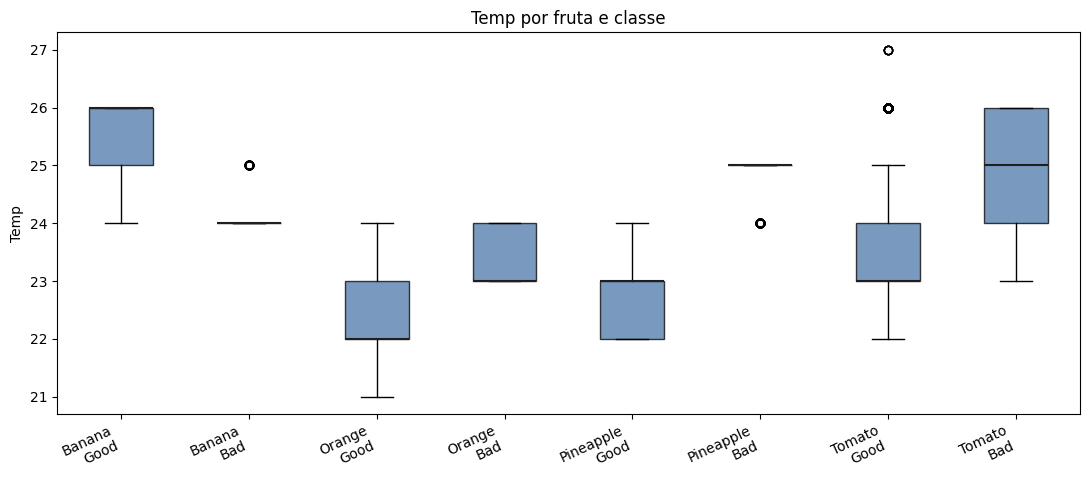

In [17]:
boxplot_sensor("Temp")

### Umidade

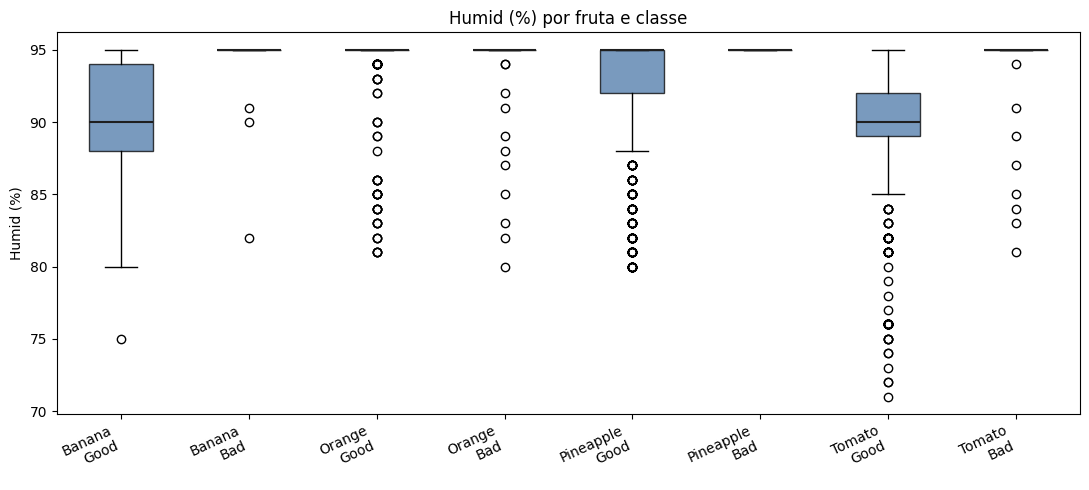

In [18]:
boxplot_sensor("Humid (%)")

### CO2

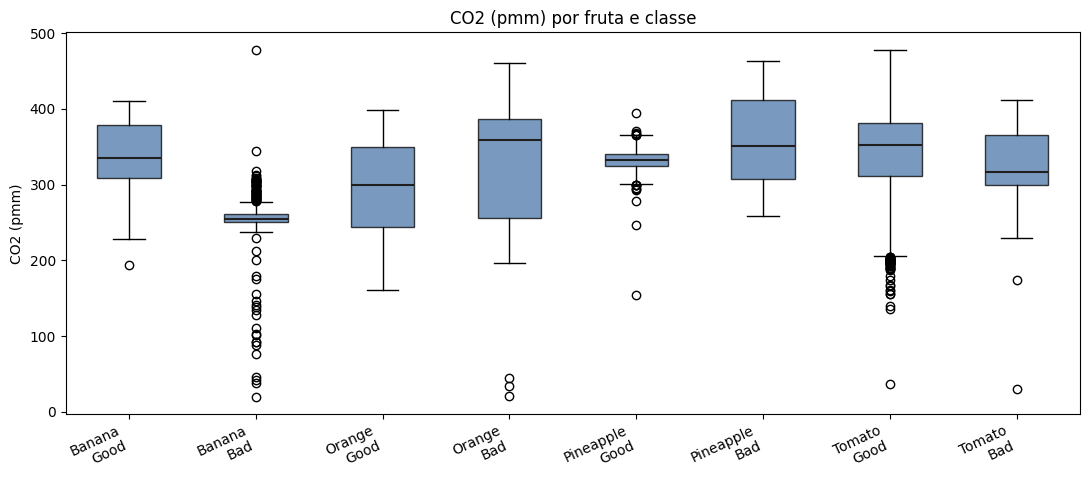

In [19]:
boxplot_sensor("CO2 (pmm)")

Os boxplots mostram que a separação entre Good e Bad varia conforme a fruta e o sensor. Diferentemente do padrão observado com Light em Orange, os sensores restantes ainda apresentam alguma sobreposição entre as classes.



No entanto, vale uma análise separada para Pineapple, onde Temp apresenta uma separação quase completa entre Good e Bad. Para essa fruta, os rótulos apresentam uma fronteira muito simples em relação à temperatura, algo que qualquer modelo baseado em árvores tende a explorar com facilidade.

Inclusive, cabe a provocação de que um simples Decision Stump já conseguiria explorar grande parte dessa separação, alcançando um desempenho elevado.

No entanto, Temp será mantida porque não apresentou problema de qualidade ou inconsistência de medição tão explícito como no caso de Light. Somado a isso, há também a grande importância da temperatura para o monitoramento.

A consequência disso é que métricas futuras muito altas para Pineapple deverão ser interpretadas com cuidado.

## Informação mútua por fruta

A informação mútua mede quanto cada sensor reduz a incerteza sobre a classe, sem exigir uma relação linear. Como a proporção entre Good e Bad muda entre as frutas, os valores são normalizados pela entropia do alvo de cada grupo.

O cálculo é repetido em 20 seeds. A correlação de Spearman entre cada repetição e o resultado médio verifica se a ordem dos sensores permanece estável.

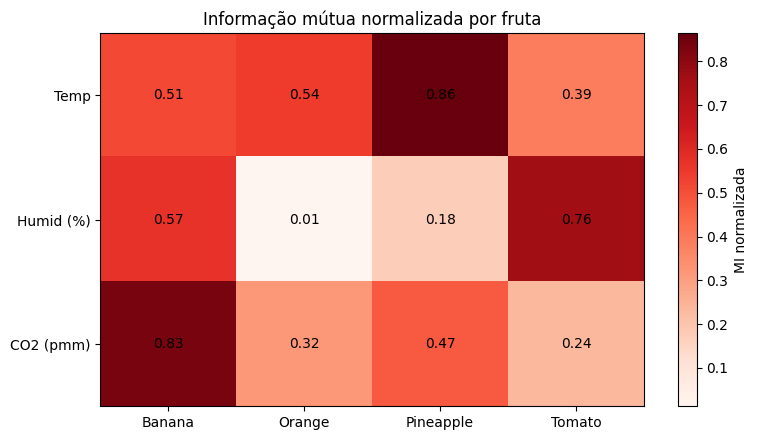

In [20]:
mi_media = pd.DataFrame(index=sensores_modelagem, columns=ordem_frutas, dtype=float)
estabilidade = []

for fruta in ordem_frutas:
    grupo = dados_modelagem[dados_modelagem["Fruit"] == fruta]
    X = grupo[sensores_modelagem]
    y = (grupo["Class"] == "Bad").astype(int).to_numpy()
    h = entropia_alvo(y)

    repeticoes = []
    for semente in range(20):
        valores = mutual_info_classif(
            X,
            y,
            discrete_features=False,
            random_state=semente
        ) / h
        repeticoes.append(valores)

    repeticoes = np.array(repeticoes)
    media = repeticoes.mean(axis=0)

    mi_media[fruta] = media

    rhos = [
        spearmanr(repeticao, media).statistic
        for repeticao in repeticoes
    ]

    estabilidade.append({
        "Fruit": fruta,
        "menor Spearman": np.min(rhos),
        "Spearman mediano": np.median(rhos),
        "maior desvio MI": repeticoes.std(axis=0).max()
    })

fig = plt.figure(figsize=(8, 4.5))
ax = fig.add_subplot(111)
imagem = ax.imshow(mi_media.values, aspect="auto", cmap="Reds")

ax.set_xticks(range(len(ordem_frutas)))
ax.set_xticklabels(ordem_frutas)
ax.set_yticks(range(len(sensores_modelagem)))
ax.set_yticklabels(sensores_modelagem)
ax.set_title("Informação mútua normalizada por fruta")

for i in range(len(sensores_modelagem)):
    for j in range(len(ordem_frutas)):
        ax.text(
            j,
            i,
            f"{mi_media.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

fig.colorbar(imagem, ax=ax, label="MI normalizada")
plt.tight_layout()
plt.show()

In [21]:
display(
    pd.DataFrame(estabilidade)
    .set_index("Fruit")
    .round(3)
)

,menor Spearman,Spearman mediano,maior desvio MI
Fruit,,,
Banana,1.0,1.0,0.012
Orange,1.0,1.0,0.014
Pineapple,1.0,1.0,0.018
Tomato,1.0,1.0,0.007


A variação na relevância dos sensores mostra que a relação entre as variáveis e a classe não segue o mesmo padrão nas quatro frutas.

Os rankings permaneceram idênticos nas 20 seeds, com correlação de Spearman igual a 1,0 em todas as frutas. Isso indica que a ordem de relevância dos sensores não depende da seed utilizada no estimador.

Como a estrutura de relevância dos sensores muda entre as frutas e cada categoria possui amostra suficiente, a modelagem seguirá com **quatro classificadores especializados**, um para cada fruta.

## Redundância operacional entre sensores

A última decisão sobre as variáveis é operacional. Se dois sensores apresentassem uma associação monotônica muito forte, um deles poderia ser removido em uma implementação futura, reduzindo custos e manutenção.

A correlação de Spearman é usada aqui para medir essa associação entre os sensores. Um valor absoluto a partir de 0,80 será tratado como sinal de potencial redundância forte.

In [22]:
def matriz_correlacao(fruta):
    correlacao = (
        dados_modelagem.loc[
            dados_modelagem["Fruit"] == fruta,
            sensores_modelagem
        ]
        .corr(method="spearman")
    )

    fig = plt.figure(figsize=(5, 4))
    ax = fig.add_subplot(111)
    imagem = ax.imshow(correlacao.values, vmin=-1, vmax=1, cmap="coolwarm")

    ax.set_xticks(range(len(sensores_modelagem)))
    ax.set_xticklabels(sensores_modelagem, rotation=25, ha="right")
    ax.set_yticks(range(len(sensores_modelagem)))
    ax.set_yticklabels(sensores_modelagem)
    ax.set_title(f"Correlação de Spearman | {fruta}")

    for i in range(len(sensores_modelagem)):
        for j in range(len(sensores_modelagem)):
            ax.text(
                j,
                i,
                f"{correlacao.iloc[i, j]:.2f}",
                ha="center",
                va="center"
            )

    fig.colorbar(imagem, ax=ax, label="Spearman")
    plt.tight_layout()
    plt.show()

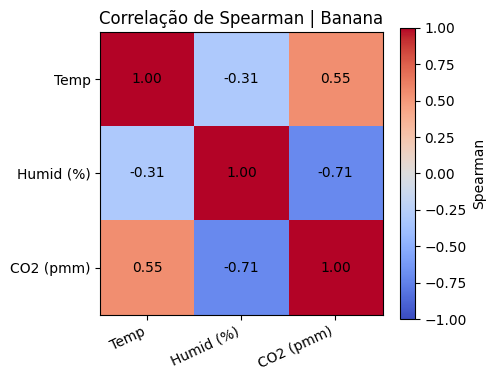

In [23]:
matriz_correlacao("Banana")

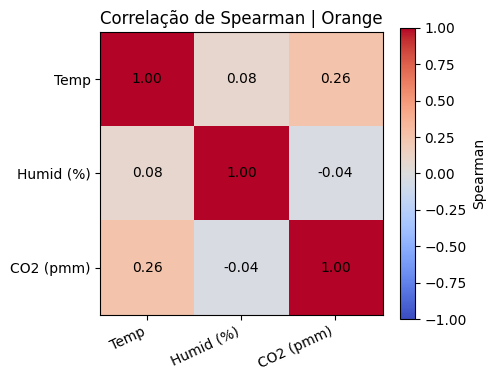

In [24]:
matriz_correlacao("Orange")

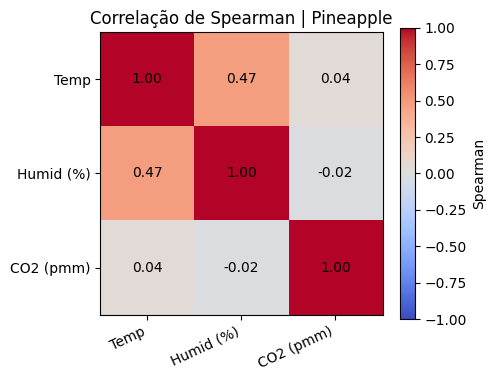

In [25]:
matriz_correlacao("Pineapple")

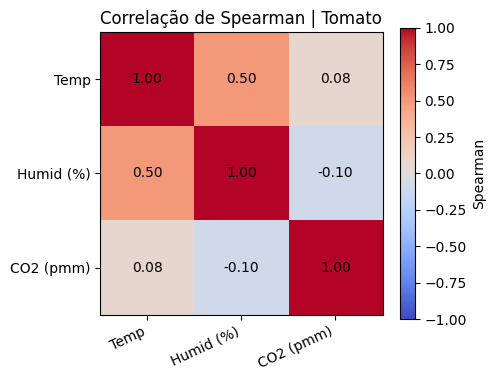

In [26]:
matriz_correlacao("Tomato")

Nenhuma fruta apresenta um par de sensores com redundância significativamente forte. Portanto, os sensores Temp, Humid ou CO2 seguem como features para os quatro classificadores.

## Limitações

Entre as bases públicas avaliadas para o protótipo, este conjunto foi escolhido por reunir as quatro frutas e as medições ambientais necessárias ao projeto. Segundo a própria fonte, a classe representa se as condições ambientais são ótimas ou subótimas para prevenção da deterioração. O processo exato de rotulagem não é documentado com profundidade suficiente para assumir que as relações encontradas se repetirão em um ambiente real.

A EDA também encontrou fronteiras muito simples entre algumas medições e a classe. Isso pode produzir métricas de classificação muito altas.

A validação de uso operacional exigiria dados coletados pelo próprio sistema em diferentes condições de armazenamento.

## Conclusão

A base final contém 8.115 registros únicos. As duplicatas exatas foram removidas, enquanto as 482 observações do bloco final de Tomato foram mantidas.

Light não seguirá para o treinamento. A decisão combina a concentração abrupta de leituras altas no final do arquivo em Tomato Bad com a separação completa entre Good e Bad em Orange.

Temp, Humid e CO2 seguem como features da modelagem. A informação mútua mostra perfis de relevância diferentes e estáveis entre as frutas, sustentando o uso de quatro classificadores especializados, um por fruta. A análise de correlação não encontrou redundância forte que justifique retirar outro sensor.

Os boxplots também mostram que algumas fronteiras continuam simples mesmo após a retirada de Light, em especial Temp em Pineapple. Isso pode levar a métricas muito altas mesmo em validação e teste, que deverão ser interpretadas junto dessa característica do conjunto e não como evidência de robustez do modelo em produção real.